# Python - PY4
## Modulo 2: Machine Learning Avanzado y Feature Engineering
### Teoria de ML y Exploracion de Datos

**Escenario de negocio:** E-commerce Shopper Intention

Trabajas como analista de datos para un e-commerce. El equipo de Marketing quiere saber **por que** un visitante compra o no compra, mientras que la gerencia quiere el modelo con la **mejor precision posible** para automatizar decisiones (por ejemplo, mostrar o no un descuento).

Vamos a entrenar varios tipos de modelos, compararlos y entregar una recomendacion final.

---

**Este modulo esta dividido en 3 notebooks:**

| Notebook | Contenido principal |
|---|---|
| 1 (este) | Teoria de ML, exploracion de datos (EDA), Feature Engineering basico, train/test split |
| 2 | Modelo interpretable (Regresion Logistica), evaluacion con Recall y Precision |
| 3 | Modelo de caja negra (Random Forest), comparacion de modelos, reporte ejecutivo |

**Objetivos de este notebook:**
- Entender la diferencia entre programacion tradicional y Machine Learning.
- Conocer las "personalidades" de los principales algoritmos de aprendizaje supervisado.
- Explorar el dataset de e-commerce y entender el problema de negocio.
- Preparar los datos (Feature Engineering basico) y hacer el train/test split.


## 1. El cambio de paradigma

En programacion tradicional, nosotros escribimos las reglas:

```python
if tiempo_en_pagina > 300:
    compra = True
```

En Machine Learning, le damos al algoritmo los datos (**inputs**) y las respuestas correctas (**outputs**), y el algoritmo aprende las reglas por si mismo.

**Componentes clave:**
- **Features (X):** las variables que usamos para predecir (por ejemplo: tiempo en la pagina, cantidad de paginas visitadas, mes del anio).
- **Target (y):** lo que queremos predecir. En nuestro caso, la columna `Revenue` (True si el visitante compro, False si no).
- **Split:** la regla de oro es nunca evaluar con los mismos datos que usamos para entrenar. Por eso dividimos en Train (80%) y Test (20%).


## 2. La caja de herramientas del aprendizaje supervisado

No todos los algoritmos son iguales: cada uno tiene una forma distinta de "pensar" y funciona mejor en ciertos escenarios. Aqui va un resumen rapido de lo que viste en la teoria (no vamos a programar todos en este modulo, pero es importante que sepas cuando usar cada uno):

| Algoritmo | Como piensa | Cuando usarlo |
|---|---|---|
| **Naive Bayes** | Calcula probabilidades asumiendo que las variables son independientes | Texto, spam, NLP |
| **LDA** | Proyecta los datos en un eje que maximiza la separacion entre clases | Reduccion de dimensionalidad, senales |
| **Regresion Lasso (L1)** | Regresion con penalizacion que puede eliminar variables inutiles (las vuelve cero) | Seleccion automatica de variables |
| **Regresion Ridge (L2)** | Regresion con penalizacion que reduce todos los coeficientes sin eliminarlos | Cuando todas las variables aportan algo |
| **KNN** | Mira a los K vecinos mas cercanos y vota | Estructura geografica o de "vecindad" |
| **SVM** | Busca la "calle" mas ancha que separe las clases (usa kernels para casos no lineales) | Pocos datos, muchas dimensiones |
| **Random Forest (Ensemble)** | Combina cientos de arboles de decision entrenados con datos y variables aleatorias | Maxima precision, datos mixtos |

**Para este modulo, nos enfocamos en dos:**
- **Regresion Logistica** (interpretable, facil de explicar a Marketing) -> Notebook 2.
- **Random Forest** (caja negra, mejor precision) -> Notebook 3.


## 3. Preparando el entorno de trabajo

Vamos a importar las librerias que usaremos durante los 3 notebooks. Si en algun momento del curso necesitas una libreria adicional, agregala aqui.


In [1]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

# Configuracion de graficos
plt.rcParams["figure.figsize"] = (8, 5)


## 4. Carga de datos

Cargamos el dataset directamente desde el repositorio del curso.


In [2]:
BASE_URL = "https://raw.githubusercontent.com/Camille-Le-Roy/data_analytics_resources/main/Module_02_machine_learning_and_feature_engineering/"
df = pd.read_csv(BASE_URL + "online_shoppers_intention.csv")

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 5. Exploracion inicial (EDA)

Antes de entrenar cualquier modelo, necesitamos entender los datos:
- Cuantas filas y columnas tenemos.
- Que tipo de dato tiene cada columna (numerica o categorica).
- Si hay valores nulos.
- Como esta distribuida nuestra variable objetivo `Revenue`.


### Diccionario de datos: Online Shoppers Purchasing Intention

- **Administrative**: cantidad de paginas de tipo "administrativas" (ej. cuenta, informacion de contacto) que el visitante recorrio durante la sesion.
- **Administrative_Duration**: tiempo total (en segundos) que el visitante paso en paginas administrativas.
- **Informational**: cantidad de paginas de tipo "informativas" (ej. politicas de envio, preguntas frecuentes) que el visitante recorrio.
- **Informational_Duration**: tiempo total (en segundos) que el visitante paso en paginas informativas.
- **ProductRelated**: cantidad de paginas relacionadas con productos que el visitante recorrio.
- **ProductRelated_Duration**: tiempo total (en segundos) que el visitante paso en paginas de producto.
- **BounceRates**: porcentaje de visitantes que entraron a esa pagina y se fueron del sitio sin generar ninguna otra interaccion (rebote).
- **ExitRates**: porcentaje de veces que esa pagina fue la ultima vista en la sesion, sobre el total de vistas a esa pagina.
- **PageValues**: valor promedio de la pagina en terminos de cuanto contribuyo a que el visitante llegara a una compra. Es una metrica ya calculada por Google Analytics.
- **SpecialDay**: que tan cerca esta la sesion de una fecha especial (ej. Dia de la Madre, San Valentin). Va de 0 (lejos de la fecha) a 1 (el mismo dia).
- **Month**: mes del anio en que ocurrio la sesion.
- **OperatingSystems**: codigo numerico que identifica el sistema operativo usado por el visitante.
- **Browser**: codigo numerico que identifica el navegador usado por el visitante.
- **Region**: codigo numerico que identifica la region geografica del visitante.
- **TrafficType**: codigo numerico que identifica el tipo de trafico por el cual el visitante llego al sitio (ej. busqueda organica, anuncio pagado, referido).
- **VisitorType**: indica si el visitante es "New_Visitor" (nuevo), "Returning_Visitor" (recurrente) u "Other" (otro).
- **Weekend**: indica si la sesion ocurrio en fin de semana (True) o no (False).
- **Revenue**: variable objetivo (target). Indica si la sesion termino en una compra (True) o no (False).

In [3]:
# Forma del dataset y tipos de dato
print("Filas y columnas:", df.shape)
df.info()


Filas y columnas: (12330, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64

In [4]:
# Valores nulos por columna
df.isnull().sum()


,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [5]:
# Distribucion de la variable objetivo
df["Revenue"].value_counts(normalize=True) # normalize = True para ver percentaje


,proportion
Revenue,
False,0.845255
True,0.154745


### Nota importante: desbalance de clases

Fijate en el resultado anterior. Lo mas probable es que la gran mayoria de los visitantes **no** haya comprado (`Revenue = False`). Este desbalance es clave: si un modelo predijera siempre "no compra", tendria un Accuracy muy alto y aun asi seria un modelo inutil para el negocio.

Esto es exactamente por lo que en los Notebooks 2 y 3 no vamos a confiar solo en el Accuracy, sino tambien en **Precision** y **Recall**.


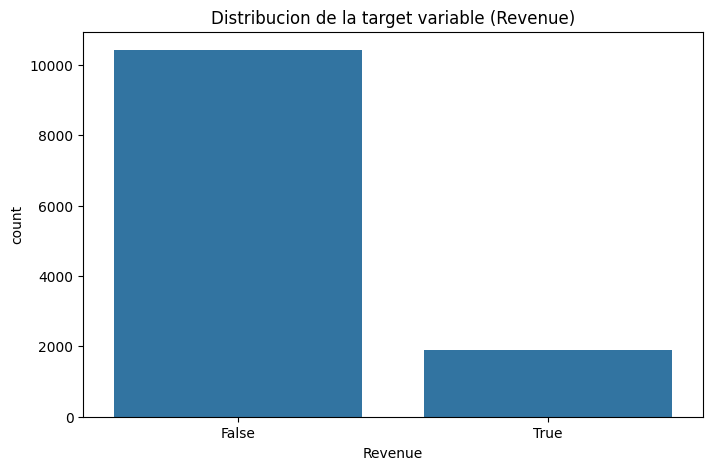

In [20]:
# Visualizamos el desbalance de clases
sns.countplot(data=df, x="Revenue") # countplot es muestra la frecuencia de una variable categórica
plt.title("Distribucion de la target variable (Revenue)")
plt.show()


## 6. Explorando la relacion entre las variables y la compra

Ya sabemos que el dataset esta desbalanceado. Ahora vamos un paso mas alla: antes de transformar los datos, queremos ver **como se comporta cada variable segun si el visitante compro o no**. Esto nos da pistas muy valiosas sobre cuales columnas van a ser mas utiles para el modelo.

Vamos a mirar esto en 4 pasos:
1. Comparar los promedios de las variables numericas entre compradores y no compradores.
2. Visualizar con boxplots las variables que mas destacan.
3. Calcular la correlacion de cada variable numerica con `Revenue`.
4. Calcular la tasa de conversion por categoria en las variables categoricas.


### 6.1 Promedios de las variables numericas por grupo

Una forma rapida de detectar variables importantes es comparar el promedio de cada variable numerica entre el grupo que compro (`Revenue = True`) y el que no (`Revenue = False`). Si el promedio es muy distinto entre los dos grupos, es una senial de que esa variable puede ayudar al modelo a distinguir entre ambos.


In [7]:
# Seleccionamos las columnas numericas
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
print("Columnas numericas:", columnas_numericas)

# Comparamos el promedio de cada variable numerica segun Revenue ("No compra" (False) y "Compra" (True))
df.groupby("Revenue")[columnas_numericas].mean().T # ".T" hace una transposicion (inversion file y columna). Unstack es similar pero cuando tenemos jerarquia (groupby varios columnas)


Columnas numericas: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']


Revenue,False,True
Administrative,2.117732,3.393606
Administrative_Duration,73.740111,119.483244
Informational,0.451833,0.786164
Informational_Duration,30.236237,57.611427
ProductRelated,28.714642,48.210168
ProductRelated_Duration,1069.987809,1876.209615
BounceRates,0.025317,0.005117
ExitRates,0.047378,0.019555
PageValues,1.975998,27.264518
SpecialDay,0.068432,0.023166


### 6.2 Visualizando las variables mas prometedoras con boxplots

`PageValues`, `BounceRates` y `ExitRates` suelen mostrar diferencias claras entre compradores y no compradores. Un boxplot nos permite ver no solo el promedio, sino tambien la dispersion y los valores atipicos (outliers) de cada grupo.


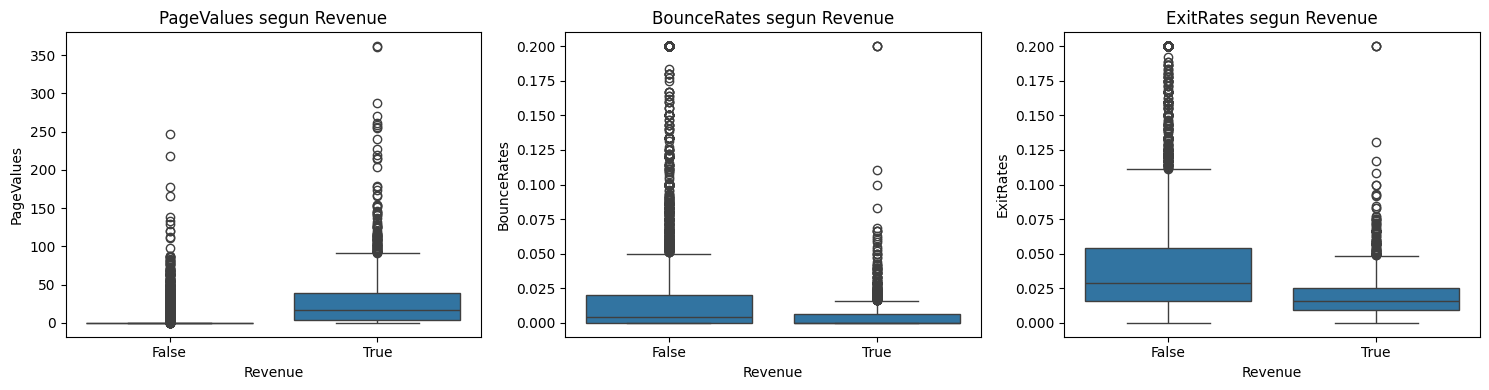

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, columna in zip(axes, ["PageValues", "BounceRates", "ExitRates"]):
    sns.boxplot(data=df, x="Revenue", y=columna, ax=ax)
    ax.set_title(f"{columna} segun Revenue")

plt.tight_layout()
plt.show()


### 6.3 Correlacion de las variables numericas con Revenue

La correlacion nos da un numero entre -1 y 1 que resume que tan relacionada esta cada variable con la compra:
- Cercano a **1**: relacion positiva fuerte (cuando la variable sube, la probabilidad de compra tambien sube).
- Cercano a **-1**: relacion negativa fuerte (cuando la variable sube, la probabilidad de compra baja).
- Cercano a **0**: poca o ninguna relacion lineal.

Nota: la correlacion solo detecta relaciones lineales, pero igual es un buen primer filtro.


In [9]:
# Convertimos Revenue a numero para poder calcular la correlacion
df_temp = df.copy()
df_temp["Revenue"] = df_temp["Revenue"].astype(int)

correlacion_con_revenue = df_temp[columnas_numericas + ["Revenue"]].corr()["Revenue"].sort_values(ascending=False)
correlacion_con_revenue


,Revenue
Revenue,1.000000
PageValues,0.492569
ProductRelated,0.158538
ProductRelated_Duration,0.152373
Administrative,0.138917
Informational,0.095200
Administrative_Duration,0.093587
Informational_Duration,0.070345
Browser,0.023984
TrafficType,-0.005113


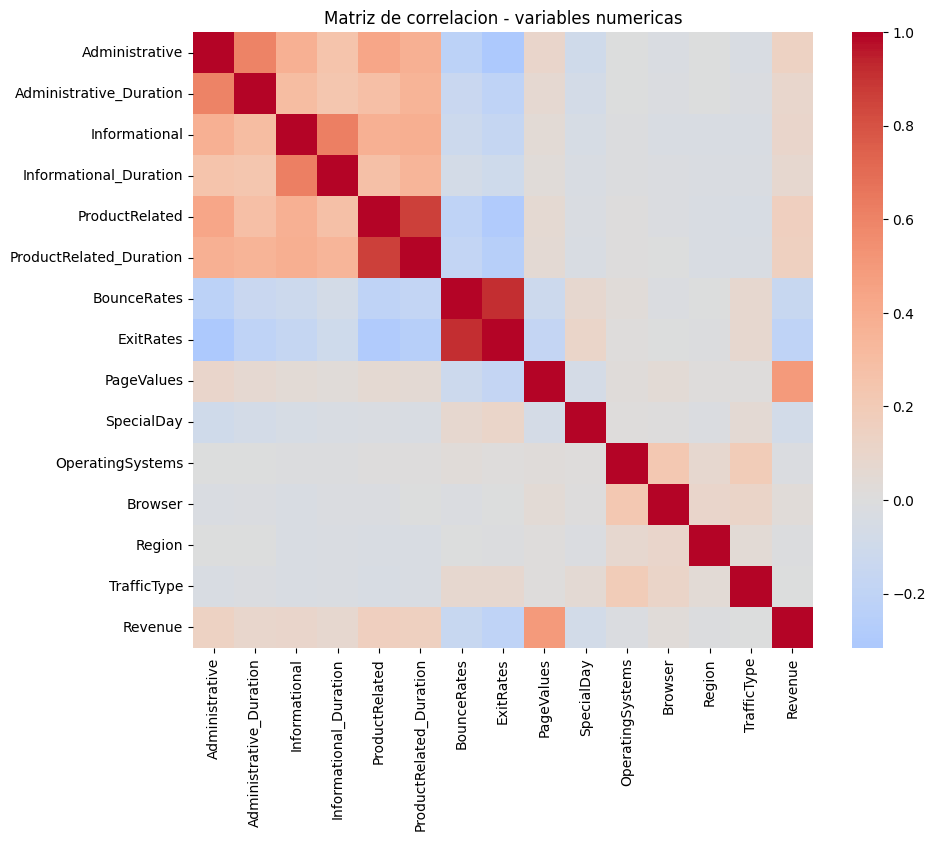

In [10]:
# Heatmap de correlacion entre todas las variables numericas
plt.figure(figsize=(10, 8))
sns.heatmap(df_temp[columnas_numericas + ["Revenue"]].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlacion - variables numericas")
plt.show()


### 6.4 Variables categoricas: tasa de conversion por categoria

Para las variables categoricas (`Month`, `VisitorType`, `Weekend`) la correlacion no aplica directamente. En su lugar, calculamos la **tasa de conversion** (conversion rate): que porcentaje de los visitantes de cada categoria termino comprando.


In [11]:
for columna in ["Month", "VisitorType", "Weekend"]:
    tasa_conversion = df.groupby(columna)["Revenue"].mean().sort_values(ascending=False)
    print(f"\nTasa de conversion por {columna}:")
    print(tasa_conversion)



Tasa de conversion por Month:
Month
Nov     0.253502
Oct     0.209472
Sep     0.191964
Aug     0.175520
Jul     0.152778
Dec     0.125072
May     0.108502
June    0.100694
Mar     0.100682
Feb     0.016304
Name: Revenue, dtype: float64

Tasa de conversion por VisitorType:
VisitorType
New_Visitor          0.249115
Other                0.188235
Returning_Visitor    0.139323
Name: Revenue, dtype: float64

Tasa de conversion por Weekend:
Weekend
True     0.173989
False    0.148911
Name: Revenue, dtype: float64


/tmp/ipykernel_4362/2512489056.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa_por_mes.index, y=tasa_por_mes.values, palette="viridis")


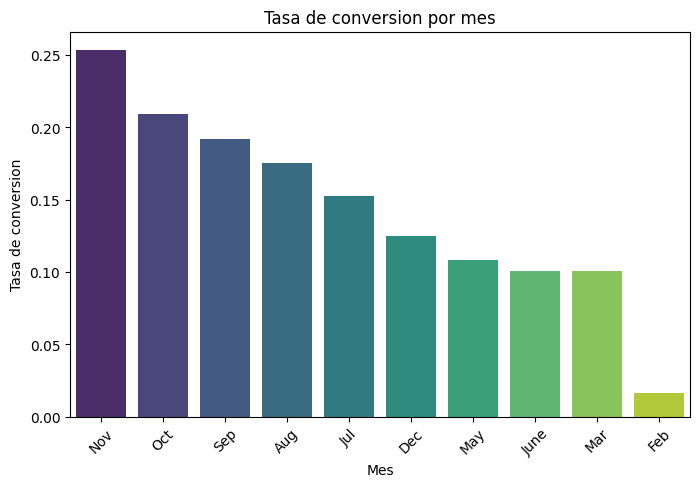

In [12]:
# Visualizamos la tasa de conversion por mes
tasa_por_mes = df.groupby("Month")["Revenue"].mean().sort_values(ascending=False)

sns.barplot(x=tasa_por_mes.index, y=tasa_por_mes.values, palette="viridis")
plt.ylabel("Tasa de conversion")
plt.xlabel("Mes")
plt.title("Tasa de conversion por mes")
plt.xticks(rotation=45)
plt.show()


### Que nos llevamos de esta exploracion

Con los promedios por grupo, los boxplots, la correlacion y las tasas de conversion, ya tienes varias piezas de evidencia sobre que variables se relacionan mas con la compra. Guarda estas observaciones: te van a servir para responder la pregunta reflexiva del cierre de este notebook, y para comparar mas adelante contra lo que el modelo (Regresion Logistica y Random Forest) considere importante.


## 7. Feature Engineering basico

Los modelos de Machine Learning necesitan numeros, no texto. Tenemos columnas categoricas como `Month`, `VisitorType` y `Weekend` que hay que convertir a formato numerico.

Usaremos `pd.get_dummies()` para hacer *one-hot encoding*: cada categoria se convierte en una columna binaria (0 o 1).


In [13]:
# Identificamos columnas categoricas
columnas_categoricas = df.select_dtypes(include="object").columns.tolist()
print("Columnas categoricas:", columnas_categoricas)

# Valores unicas en cada columns categoricas
print(df['Month'].unique())
print(df['VisitorType'].unique())

# One-hot encoding de las variables categoricas
df_encoded = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True) # drop_first=True para eliminar la columna redundante

# La columna Weekend puede venir como booleano, la convertimos a entero por seguridad
df_encoded["Weekend"] = df_encoded["Weekend"].astype(int)
df_encoded["Revenue"] = df_encoded["Revenue"].astype(int)

df_encoded.head()


Columnas categoricas: ['Month', 'VisitorType']
['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']
['Returning_Visitor' 'New_Visitor' 'Other']


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True


# El Problema de One-Hot Encoding con Alta Cardinalidad

Cuando una variable tiene cientos de categorías únicas (ej. códigos postales o ciudades), aplicar One-Hot Encoding crea una columna nueva para cada categoría, rompiendo la estructura de tu dataset.

## 3 Problemas Críticos:

1. **Maldición de la dimensionalidad:** El dataset crece horizontalmente y se vuelve **extremadamente disperso** (lleno de ceros), dificultando el aprendizaje del modelo.
2. **Sobrecarga de memoria:** El consumo de memoria RAM se dispara, ralentizando drásticamente los tiempos de entrenamiento.
3. **Fallo en modelos de árboles:** Algoritmos como *Random Forest* o *XGBoost* no pueden lidiar con tantas columnas dispersas. La importancia de cada variable se diluye y los árboles terminan ignorándolas.

---

## ¿Qué usar en su lugar?
Para alta cardinalidad, usa técnicas que extraigan información **sin añadir columnas extras**:

*   **Target Encoding:** Reemplaza la categoría por el promedio de la target variable en ese grupo (ideal para árboles, pero requiere cuidado para evitar sobreajuste).
*   **Frequency Encoding:** Sustituye la categoría por su número total de apariciones o porcentaje de peso en el dataset.
*   **Feature Hashing:** Mapea múltiples categorías en un número fijo y pequeño de columnas usando funciones hash.

## 8. Separando Features (X) y Target (y)

Ahora separamos nuestras variables predictoras (X) de la variable que queremos predecir (y).


In [14]:
X = df_encoded.drop(columns=["Revenue"]) # las variable predictoras son todas except la target variable.
y = df_encoded["Revenue"]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)


Shape de X: (12330, 26)
Shape de y: (12330,)


## 9. Train/Test Split



### ¿Por qué dividimos los datos en 80% Entrenamiento y 20% Prueba?

La mejor forma de entenderlo es pensar en un **examen final**. Si un estudiante practica con las mismas preguntas exactas que vendrán en el examen, no aprenderá la materia; solo memorizará las respuestas. En Machine Learning, esto se llama **sobreajuste (overfitting)**.

Para evitarlo, dividimos los datos:

*   **El Conjunto de Entrenamiento (80%):** Son los libros y las tareas del estudiante. El modelo usa este gran volumen de datos para buscar patrones, equivocarse y ajustar sus ecuaciones matemáticas.
*   **El Conjunto de Prueba (20%):** Es el **Examen Final**. Son datos ocultos que el modelo jamás ve durante su entrenamiento.






Dividimos los datos en un set de entrenamiento (80%) y un set de prueba (20%). Usamos `stratify=y` para asegurarnos de que la proporcion de compradores/no compradores se mantenga igual en ambos sets (importante por el desbalance que vimos antes).


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, # Pasamos la matriz de features (X) y la target variable (y)
    test_size=0.20, # queremos 20% de los datos en el test set
    random_state=42, # para que la división sea reproducible
    stratify=y # Mantiene la proporción original de True/False en ambos bloques (esencial)
)

print("Tamanio de entrenamiento:", X_train.shape)
print("Tamanio de prueba:", X_test.shape)


Tamanio de entrenamiento: (9864, 26)
Tamanio de prueba: (2466, 26)


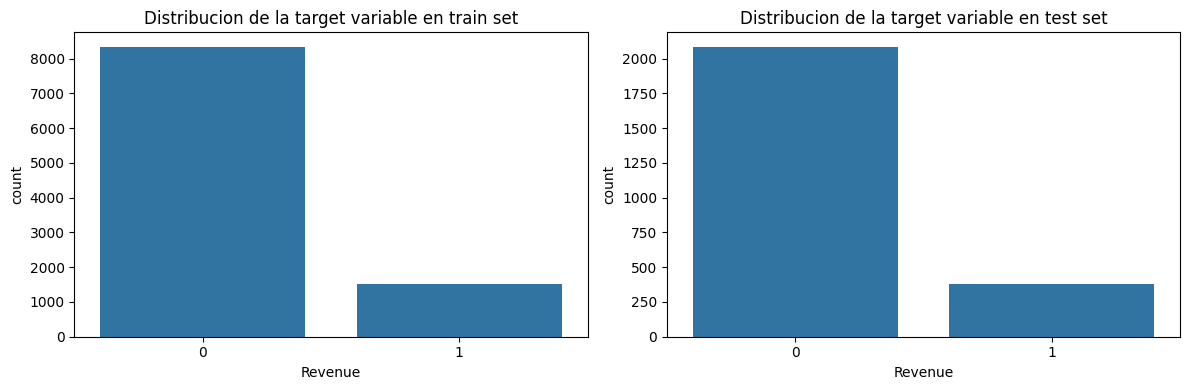

In [21]:
# verificamos que proporción de True/False es similar en el train y test set

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Train set")
axes[0].set_xlabel("Revenue")

sns.countplot(x=y_test, ax=axes[1])
axes[1].set_title("Test set")
axes[1].set_xlabel("Revenue")

plt.tight_layout()
plt.show()

## 10. Guardando nuestro trabajo para el siguiente notebook

En el Notebook 2 vamos a necesitar `X_train`, `X_test`, `y_train`, `y_test` y `X` (para ver los nombres de las columnas). Guardamos estas variables en disco con `pickle` para no tener que repetir todo el proceso.


In [ ]:
import pickle

with open("datos_procesados.pkl", "wb") as f:
    pickle.dump((X, X_train, X_test, y_train, y_test), f)

print("Datos guardados en 'datos_procesados.pkl'")


Datos guardados en 'datos_procesados.pkl'
